Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3637 images belonging to 4 classes.
Found 791 images belonging to 4 classes.
Found 773 images belonging to 4 classes.
Phase 1: Training custom head (base frozen)
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1159s 20s/step - accuracy: 0.6573 - loss: 5.4575 - val_accuracy: 0.9062 - val_loss: 5.2528
Epoch 2/10
 1/56 ━━━━━━━━━━━━━━━━━━━━ 25s 458ms/step - accuracy: 0.8281 - loss: 4.7275

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - accuracy: 0.8281 - loss: 4.7275 - val_accuracy: 0.9036 - val_loss: 5.2482
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 616ms/step - accuracy: 0.9002 - loss: 4.6310 - val_accuracy: 0.9193 - val_loss: 4.9120
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.9062 - loss: 4.5047 - val_accuracy: 0.9232 - val_loss: 4.9050
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 75s 610ms/step - accuracy: 0.9068 - loss: 4.3753 - val_accuracy: 0.9089 - val_loss: 4.5706
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.9531 - loss: 4.1163 - val_accuracy: 0.9102 - val_loss: 4.5645
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 72s 611ms/step - accuracy: 0.9142 - loss: 4.1346 - val_accuracy: 0.9245 - val_loss: 4.2385
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.9375 - loss: 3.8995 - val_accuracy: 0.9180 - val_loss: 4.2375
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 75s 615ms/step - accuracy: 0.9329 - loss: 3.8814 - val_accuracy: 0.9128 

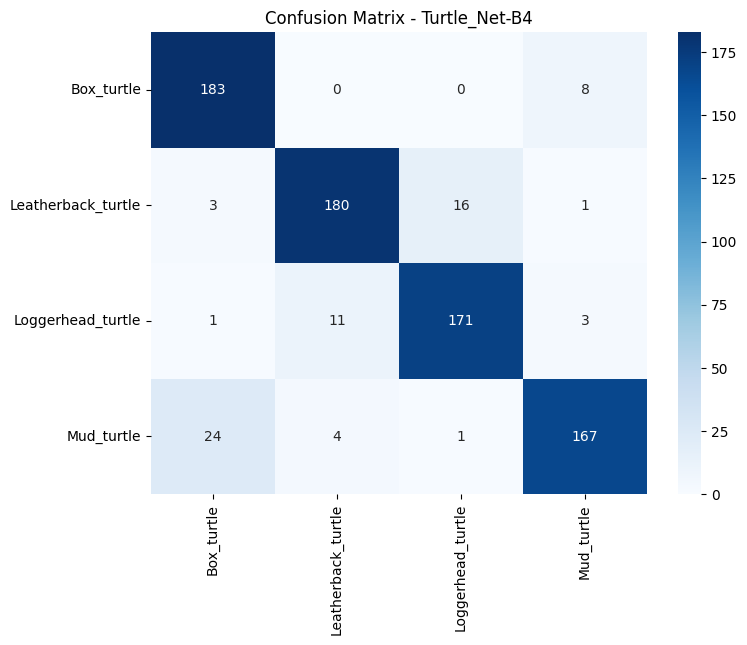

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 582ms/step


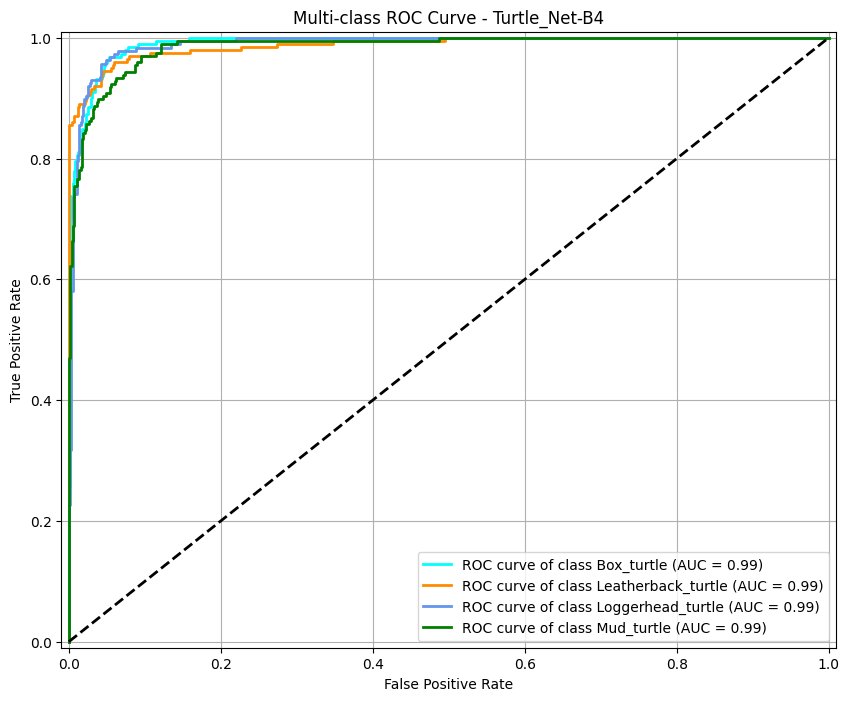

In [ ]:
# Install required packages (if not already installed)
!pip install -q tensorflow scikit-learn seaborn

# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Dataset paths
train_dir = '/content/drive/MyDrive/Turtle_classification_work/Sea_turtle_work/Sea_turtle_dataset(4 species)/Training'
validation_dir = '/content/drive/MyDrive/Turtle_classification_work/Sea_turtle_work/Sea_turtle_dataset(4 species)/Validation'
test_dir = '/content/drive/MyDrive/Turtle_classification_work/Sea_turtle_work/Sea_turtle_dataset(4 species)/Testing'

# Data generators
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Load datasets
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(380, 380),
    batch_size=64,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(380, 380),
    batch_size=64,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

# Custom Squeeze-and-Excitation (SE) Block
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

# Load EfficientNetB4 (frozen initially)
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3),
    pooling=None
)
base_model.trainable = False

# Build custom model
inputs = tf.keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = se_block(x)  # Your custom SE block
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)  # Changed to 4 classes

custom_model = models.Model(inputs, outputs, name="Turtle_Net-B4")

# Phase 1: Train only the custom head
custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training custom head (base frozen)")
history_phase1 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ]
)

# Phase 2: Fine-tune top layers of EfficientNetB4
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-tuning top layers")
history_phase2 = custom_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ]
)

# Evaluate
test_loss, test_acc = custom_model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Generate predictions
test_generator.reset()
y_pred = np.argmax(custom_model.predict(test_generator), axis=1)
y_true = test_generator.classes

# Trim predictions to match true labels (if needed)
y_pred = y_pred[:len(y_true)]

# Metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nPrecision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix - Turtle_Net-B4')
plt.show()

# Multi-class ROC Curve
# Get class labels and one-hot encode true labels
class_names = list(test_generator.class_indices.keys())
n_classes = len(class_names)
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

# Get predicted probabilities
y_score = custom_model.predict(test_generator)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - Turtle_Net-B4')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()




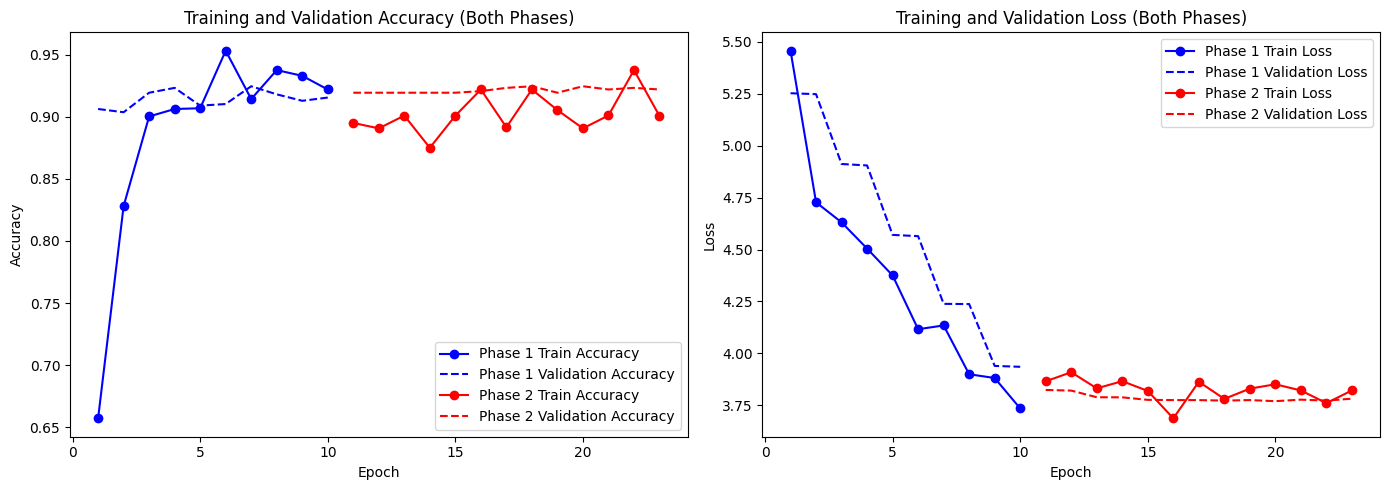

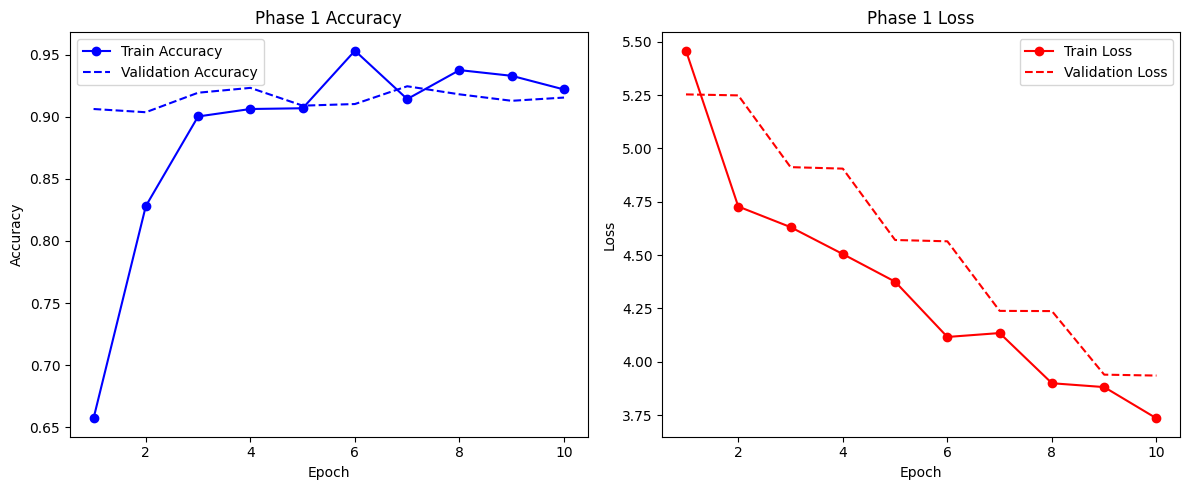

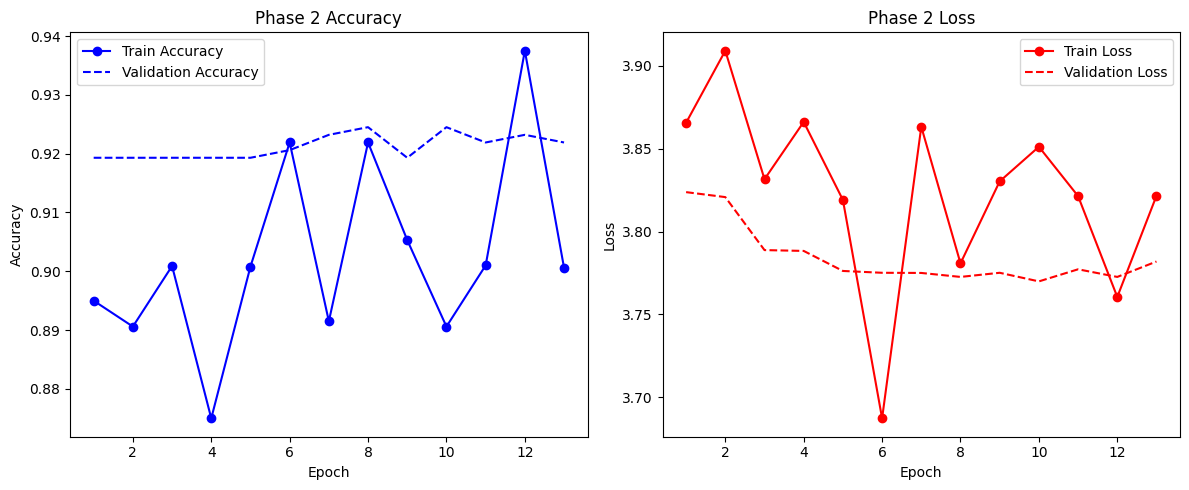

In [1]:
import matplotlib.pyplot as plt

# Phase 1 data
phase1_acc = [0.6573, 0.8281, 0.9002, 0.9062, 0.9068, 0.9531, 0.9142, 0.9375, 0.9329, 0.9219]
phase1_val_acc = [0.9062, 0.9036, 0.9193, 0.9232, 0.9089, 0.9102, 0.9245, 0.9180, 0.9128, 0.9154]
phase1_loss = [5.4575, 4.7275, 4.6310, 4.5047, 4.3753, 4.1163, 4.1346, 3.8995, 3.8814, 3.7350]
phase1_val_loss = [5.2528, 5.2482, 4.9120, 4.9050, 4.5706, 4.5645, 4.2385, 4.2375, 3.9397, 3.9354]

# Phase 2 data (only 13 epochs from logs)
phase2_acc = [0.8950, 0.8906, 0.9009, 0.8750, 0.9008, 0.9219, 0.8915, 0.9219, 0.9053, 0.8906, 0.9010, 0.9375, 0.9006]
phase2_val_acc = [0.9193, 0.9193, 0.9193, 0.9193, 0.9193, 0.9206, 0.9232, 0.9245, 0.9193, 0.9245, 0.9219, 0.9232, 0.9219]
phase2_loss = [3.8657, 3.9092, 3.8316, 3.8662, 3.8191, 3.6872, 3.8633, 3.7808, 3.8303, 3.8512, 3.8214, 3.7605, 3.8216]
phase2_val_loss = [3.8238, 3.8208, 3.7888, 3.7883, 3.7762, 3.7751, 3.7750, 3.7726, 3.7751, 3.7699, 3.7772, 3.7726, 3.7819]

phase1_epochs = range(1, len(phase1_acc) + 1)
phase2_epochs = range(1, len(phase2_acc) + 1)

# Combined plot with continuous epochs for Phase 2 shifted by Phase 1 length
plt.figure(figsize=(14, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(phase1_epochs, phase1_acc, 'bo-', label='Phase 1 Train Accuracy')
plt.plot(phase1_epochs, phase1_val_acc, 'b--', label='Phase 1 Validation Accuracy')
plt.plot([e + len(phase1_acc) for e in phase2_epochs], phase2_acc, 'ro-', label='Phase 2 Train Accuracy')
plt.plot([e + len(phase1_acc) for e in phase2_epochs], phase2_val_acc, 'r--', label='Phase 2 Validation Accuracy')
plt.title('Training and Validation Accuracy (Both Phases)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(phase1_epochs, phase1_loss, 'bo-', label='Phase 1 Train Loss')
plt.plot(phase1_epochs, phase1_val_loss, 'b--', label='Phase 1 Validation Loss')
plt.plot([e + len(phase1_loss) for e in phase2_epochs], phase2_loss, 'ro-', label='Phase 2 Train Loss')
plt.plot([e + len(phase1_loss) for e in phase2_epochs], phase2_val_loss, 'r--', label='Phase 2 Validation Loss')
plt.title('Training and Validation Loss (Both Phases)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Separate plots for Phase 1
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(phase1_epochs, phase1_acc, 'bo-', label='Train Accuracy')
plt.plot(phase1_epochs, phase1_val_acc, 'b--', label='Validation Accuracy')
plt.title('Phase 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phase1_epochs, phase1_loss, 'ro-', label='Train Loss')
plt.plot(phase1_epochs, phase1_val_loss, 'r--', label='Validation Loss')
plt.title('Phase 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Separate plots for Phase 2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(phase2_epochs, phase2_acc, 'bo-', label='Train Accuracy')
plt.plot(phase2_epochs, phase2_val_acc, 'b--', label='Validation Accuracy')
plt.title('Phase 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phase2_epochs, phase2_loss, 'ro-', label='Train Loss')
plt.plot(phase2_epochs, phase2_val_loss, 'r--', label='Validation Loss')
plt.title('Phase 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
